In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

# ── Verificar GPU ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ Usando GPU: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  GPU no encontrada, usando CPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2026-06-04 17:19:14.527000: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 17:19:14.615094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780593554.649333  187837 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780593554.661385  187837 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 17:19:14.743753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TensorFlow version: 2.18.1
✅ Usando GPU: /physical_device:GPU:0


In [ ]:
TRAIN_DIR   = '/workspace/dataset/train/'
TEST_DIR    = '/workspace/dataset/test/'

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-3
DROPOUT     = 0.2
PATIENCE    = 5
VAL_SPLIT   = 0.2
SEED        = 123
AUTOTUNE    = tf.data.AUTOTUNE

# Subconjunto para pruebas rápidas (poner None para usar el dataset completo)
TRAIN_SAMPLES = None
TEST_SAMPLES  = None

In [ ]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,   # <-- explícito
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training'
)

val_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation'
)

test_ds_full = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds_full.class_names
print(f"Clases detectadas: {class_names}")

# Subconjunto para pruebas rápidas
if TRAIN_SAMPLES:
    train_ds = train_ds_full.take(TRAIN_SAMPLES // BATCH_SIZE + 1)
    val_ds   = val_ds_full.take((TRAIN_SAMPLES // 4) // BATCH_SIZE + 1)
else:
    train_ds = train_ds_full
    val_ds   = val_ds_full

if TEST_SAMPLES:
    test_ds = test_ds_full.take(TEST_SAMPLES // BATCH_SIZE + 1)
else:
    test_ds = test_ds_full

print(f"Batches — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Found 47874 files belonging to 2 classes.
Using 38300 files for training.


I0000 00:00:1780593561.454269  187837 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22149 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


Found 47874 files belonging to 2 classes.
Using 9574 files for validation.
Found 11965 files belonging to 2 classes.
Clases detectadas: ['fake', 'real']
Batches — train: 1197, val: 300, test: 374


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_ds
    .map(resize_and_augment, num_parallel_calls=AUTOTUNE)
    #.cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    #.cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    #.cache()
    .prefetch(buffer_size=AUTOTUNE)
)

# Verificación: rango de píxeles
image_batch, labels_batch = next(iter(train_ds))
print(f"Rango de píxeles → min: {np.min(image_batch):.1f}, max: {np.max(image_batch):.1f}")
print(f"Shape del batch: {image_batch.shape}")
print(f"Etiquetas del batch: {labels_batch.numpy()[:8]}")

Rango de píxeles → min: 0.0, max: 255.0
Shape del batch: (32, 224, 224, 3)
Etiquetas del batch: [0 0 1 0 1 1 0 1]


In [ ]:
class ViTPreprocess(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406])
        self.std  = tf.constant([0.229, 0.224, 0.225])

    def call(self, x):
        return (tf.cast(x, tf.float32) / 255.0 - self.mean) / self.std

    def get_config(self):
        return super().get_config()

def build_model(img_size: int = IMG_SIZE, dropout_rate: float = DROPOUT,
                learning_rate: float = LR) -> keras.Model:
    """
    ViT con cabeza de clasificación binaria.
    backbone.trainable = False  solo se entrena la cabeza.
    """
    mean = tf.constant([0.485, 0.456, 0.406])
    std  = tf.constant([0.229, 0.224, 0.225])

    inputs = layers.Input(shape=(img_size, img_size, 3), name="images")
    inputs_vit = ViTPreprocess(name="vit_preprocess")(inputs)

    backbone_vit = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet21k")
    backbone_vit.trainable = False

    vit_output = backbone_vit({"images": inputs_vit})
    vit_features = vit_output[:, 0, :]

    base_cnn = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )

    base_cnn.trainable = False   # congelar backbone
    base_cnn_output = base_cnn(inputs, training=False)
    base_cnn_features = layers.GlobalAveragePooling2D()(base_cnn_output)

    combined_model = layers.concatenate([vit_features, base_cnn_features])

    x = layers.BatchNormalization()(combined_model)
    x = layers.Dropout(dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="pred")(x)

    model = keras.Model(inputs, outputs, name="ViT_EfficientNet")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


model = build_model()
model.summary()

trainable_params = sum(
    np.prod(v.shape) for v in model.trainable_weights
)
total_params = sum(
    np.prod(v.shape) for v in model.weights
)
print(f"\nParámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.1f}%)")

Model: "ViT_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_preprocess      │ (None, 224, 224,  │          0 │ images[0][0]      │
│ (ViTPreprocess)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vi_t_backbone       │ (None, 197, 768)  │ 85,798,656 │ vit_preprocess[0… │
│ (ViTBackbone)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ images[0][0]      │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ vi_t_backbone[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2048)      │          0 │ get_item[0][0],   │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_dropout         │ (None, 2048)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred (Dense)        │ (None, 1)         │      2,049 │ top_dropout[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 89,858,468 (342.78 MB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 89,852,323 (342.76 MB)


Parámetros entrenables: 6,145 / 89,858,468.0 (0.0%)


In [ ]:
callbacks = [
    # Guarda el mejor modelo según val_auc
    keras.callbacks.ModelCheckpoint(
        "best_model_cnn_vit_prefinetuning.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

with tf.device('/GPU:0'):
    hist = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=callbacks
    )

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(None, 224, 224, 3))']
  warnings.warn(msg)
I0000 00:00:1780590599.840400  172522 service.cc:148] XLA service 0x7c94e80031f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780590599.840529  172522 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-06-04 16:30:06.747595: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780590608.653513  172522 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-04 16:30:10.147247: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 

 105/1197 ━━━━━━━━━━━━━━━━━━━━ 2:13 122ms/step - accuracy: 0.6553 - auc: 0.7236 - loss: 0.6759

2026-06-04 16:30:31.552991: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 129/1197 ━━━━━━━━━━━━━━━━━━━━ 2:12 124ms/step - accuracy: 0.6675 - auc: 0.7380 - loss: 0.6572

...

1196/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7853 - auc: 0.8669 - loss: 0.4628

E0000 00:00:1780590842.186724  172523 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780590842.269910  172523 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780590842.461938  172523 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780590842.546798  172523 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780590842.923292  172523 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7853 - auc: 0.8669 - loss: 0.4627

2026-06-04 16:34:41.028271: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-06-04 16:35:03.427866: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98', 28 bytes spill stores, 28 bytes spill loads

2026-06-04 16:35:03.429855: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98', 284 bytes spill stores, 284 bytes spill loads

2026-06-04 16:35:03.551651: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_121', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 16:35:03.657683: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9


Epoch 1: val_auc improved from None to 0.95190, saving model to best_model_cnn_vit_prefinetuning.keras

Epoch 1: finished saving model to best_model_cnn_vit_prefinetuning.keras
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 318s 244ms/step - accuracy: 0.8249 - auc: 0.9059 - loss: 0.3952 - val_accuracy: 0.8823 - val_auc: 0.9519 - val_loss: 0.2818 - learning_rate: 0.0010
Epoch 2/100
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8495 - auc: 0.9269 - loss: 0.3485
Epoch 2: val_auc improved from 0.95190 to 0.95382, saving model to best_model_cnn_vit_prefinetuning.keras

Epoch 2: finished saving model to best_model_cnn_vit_prefinetuning.keras
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 50s 42ms/step - accuracy: 0.8526 - auc: 0.9288 - loss: 0.3440 - val_accuracy: 0.8853 - val_auc: 0.9538 - val_loss: 0.2759 - learning_rate: 0.0010
Epoch 3/100
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8519 - auc: 0.9284 - loss: 0.3460
Epoch 3: val_auc improved from 0.95382 to 0.95599, saving model to best_model_

In [15]:
def plot_history(hist, figure_name, figure_title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('loss',     'Loss',     'Loss'),
        ('accuracy', 'Accuracy', 'Accuracy'),
        ('auc',      'AUC',      'AUC'),
    ]
    for ax, (key, title, ylabel) in zip(axes, metrics):
        ax.plot(hist.history[key],     label='Train', linewidth=2)
        ax.plot(hist.history[f'val_{key}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Curvas de Entrenamiento — ViT 16x16 - Pre Finetuning', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(figure_name, dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:

fig_name = '/workspace/imagenes_metricas_full_dataset/training_curves_cnn_vit_prefinetuning_final.png'
fig_title = 'Curvas de Entrenamiento — CNN + ViT 16x16 - Pre Finetuning'
plot_history(hist, fig_name, fig_title)

In [6]:
ruta_modelo = 'best_model_cnn_vit_prefinetuning.keras'
model = tf.keras.models.load_model(
    ruta_modelo,
    custom_objects={"ViTPreprocess": ViTPreprocess}
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 406 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

2026-06-04 17:19:47.259089: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(32, 224, 224, 3))']
  warnings.warn(msg)
I0000 00:00:1780593590.542678  188070 service.cc:148] XLA service 0x71ee440188a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780593590.542702  188070 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-06-04 17:19:50.631540: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780593591.015446  188070 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-04 17:19:52.336324: I external/local_xla/xla/stream_executor/cuda

Distribución y_true: [5970 5995]
Distribución y_pred: [6075 5890]


2026-06-04 17:21:04.918604: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


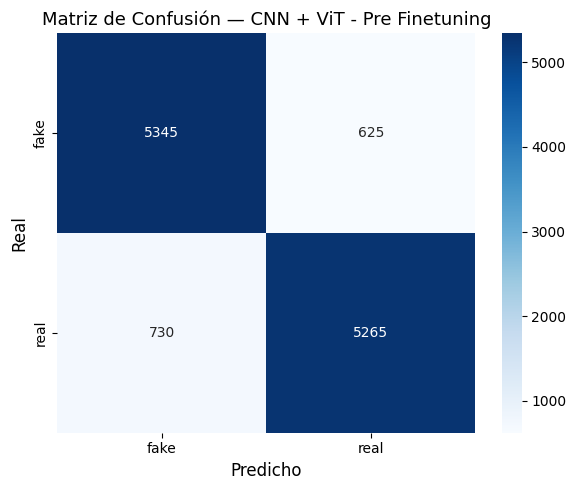


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.88      0.90      0.89      5970
        real       0.89      0.88      0.89      5995

    accuracy                           0.89     11965
   macro avg       0.89      0.89      0.89     11965
weighted avg       0.89      0.89      0.89     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — CNN + ViT - Pre Finetuning', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_cnn_vit_prefinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


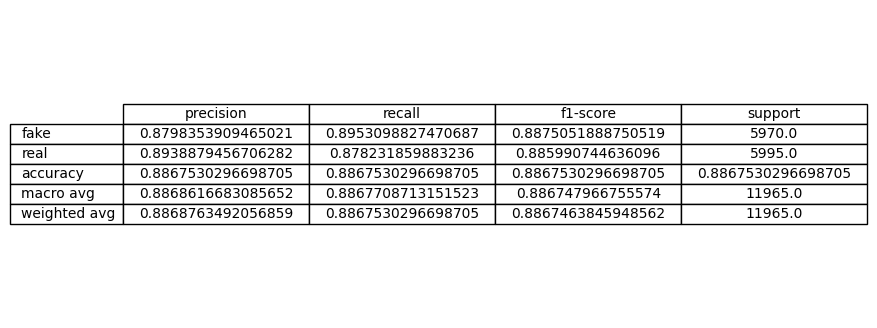

In [9]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# 4. Crear la imagen con Matplotlib
fig, ax = plt.subplots(figsize=(8, 4)) # Ajustar tamaño
ax.axis('off') # Ocultar ejes
ax.axis('tight')

# Dibujar la tabla
table = ax.table(cellText=df_report.values,
                 colLabels=df_report.columns,
                 rowLabels=df_report.index,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Ajustar escala

# 5. Guardar la imagen
plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_cnn_vit_prefinetuning_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

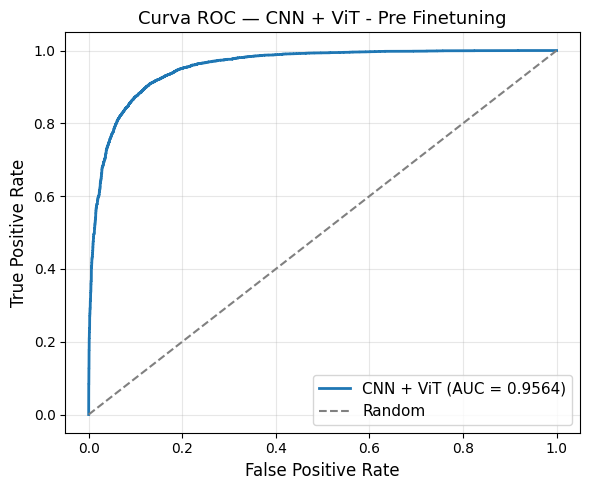

AUC final (test completo): 0.9564


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'CNN + ViT (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — CNN + ViT - Pre Finetuning', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_cnn_vit_salida_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")

In [ ]:
vit_model = model.get_layer("vi_t_backbone")
vit_model.trainable = True
encoder = vit_model.get_layer("vit_encoder")

for block in encoder.encoder_layers:
    block.trainable = False

vit_model.get_layer("vit_patching_and_embedding").trainable = False

trainable_layers = [9,10,11]

for i, block in enumerate(encoder.encoder_layers):
    if i in trainable_layers:
        block.trainable = True

encoder.layer_norm.trainable = True

cnn_model = model.get_layer("efficientnetb0")
cnn_model.trainable = True

fine_tune_at = 200

for layer in cnn_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in cnn_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

trainable_vit = sum([1 for l in encoder.encoder_layers if l.trainable])
frozen_vit   = sum([1 for l in encoder.encoder_layers if not l.trainable])
print(f"Capas entrenables del encoder del ViT: {trainable_vit} | Congeladas ViT: {frozen_vit}")

trainable_ft_vit = sum(np.prod(v.shape) for v in encoder.trainable_weights)
print(f"Parámetros entrenables en fine-tuning para el ViT: {trainable_ft_vit:,}")

trainable_cnn = sum([1 for l in cnn_model.layers if l.trainable])
frozen_cnn   = sum([1 for l in cnn_model.layers if not l.trainable])
print(f"Capas entrenables CNN: {trainable_cnn} | Congeladas CNN: {frozen_cnn}")

trainable_ft_cnn = sum(np.prod(v.shape) for v in cnn_model.trainable_weights)
print(f"Parámetros entrenables en fine-tuning para CNN: {trainable_ft_cnn:,}")



Capas entrenables del encoder del ViT: 3 | Congeladas ViT: 9
Parámetros entrenables en fine-tuning para el ViT: 21,265,152
Capas entrenables CNN: 30 | Congeladas CNN: 208
Parámetros entrenables en fine-tuning para CNN: 2,037,520


In [12]:
callbacks_ft = [
    keras.callbacks.ModelCheckpoint(
        "best_model_cnn_vit_finetuned.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
]
with tf.device('/GPU:0'):
    hist_ft = model.fit(
        train_ds,
        epochs=100,
        validation_data=val_ds,
        callbacks=callbacks_ft
    )

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(None, 224, 224, 3))']
  warnings.warn(msg)
2026-06-04 17:22:02.221691: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_225', 80 bytes spill stores, 80 bytes spill loads

2026-06-04 17:22:02.230038: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_226', 1712 bytes spill stores, 1200 bytes spill loads

2026-06-04 17:22:02.442217: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_226', 236 bytes spill stores, 236 bytes spill loads

2026-06-04 17:22:02.663598: I external/local_x

  81/1197 ━━━━━━━━━━━━━━━━━━━━ 3:06 167ms/step - accuracy: 0.8597 - auc: 0.9358 - loss: 0.3283

2026-06-04 17:22:22.741350: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 100/1197 ━━━━━━━━━━━━━━━━━━━━ 3:05 169ms/step - accuracy: 0.8608 - auc: 0.9367 - loss: 0.3254

...

1149/1197 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.9783 - auc: 0.9974 - loss: 0.0619

2026-06-04 18:40:48.749583: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9784 - auc: 0.9974 - loss: 0.0618

2026-06-04 18:41:24.245262: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile



Epoch 17: val_auc did not improve from 0.98234
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 279s 233ms/step - accuracy: 0.9789 - auc: 0.9976 - loss: 0.0597 - val_accuracy: 0.9327 - val_auc: 0.9808 - val_loss: 0.1954
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 12.


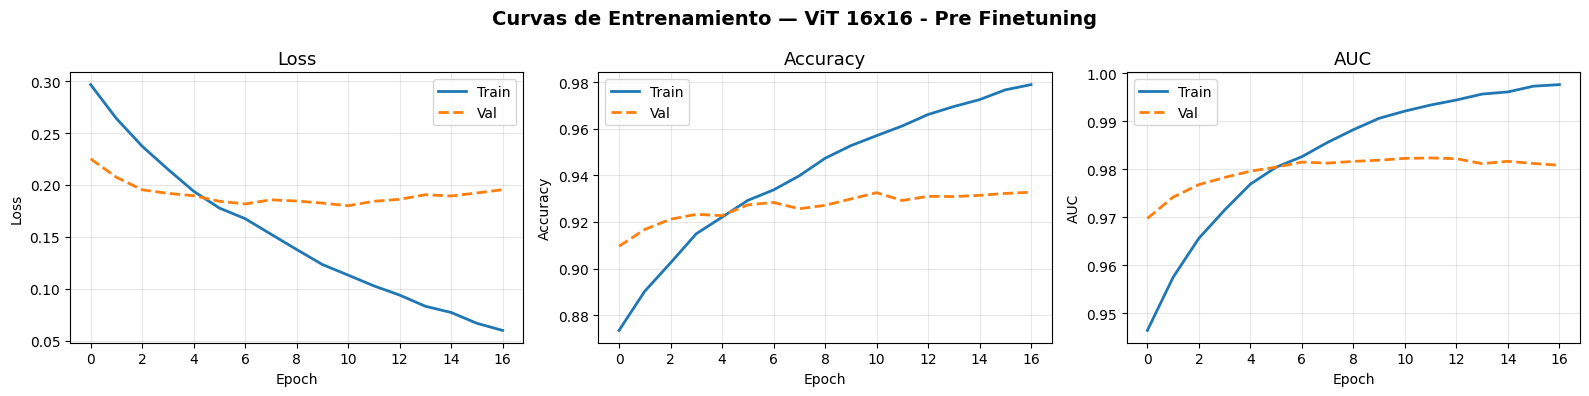

In [17]:
fig_name = '/workspace/imagenes_metricas_full_dataset/training_curves_cnn_vit_salida_postfinetuning_final.png'
fig_title = 'Curvas de Entrenamiento — CNN + ViT Base 16x16 - Post Finetuning'
plot_history(hist_ft, fig_name, fig_title)

In [ ]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

2026-06-04 19:43:30.422719: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(32, 224, 224, 3))']
  warnings.warn(msg)
Corrupt JPEG data: premature end of data segment
2026-06-04 19:44:29.530817: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


Distribución y_true: [5970 5995]
Distribución y_pred: [6252 5713]


2026-06-04 19:44:36.848687: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


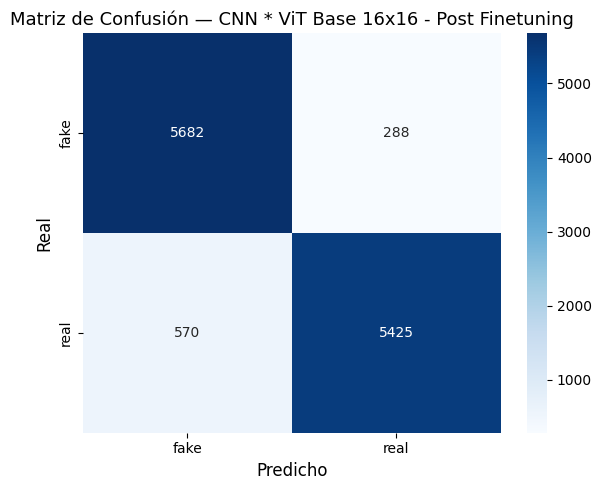


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.91      0.95      0.93      5970
        real       0.95      0.90      0.93      5995

    accuracy                           0.93     11965
   macro avg       0.93      0.93      0.93     11965
weighted avg       0.93      0.93      0.93     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — CNN * ViT Base 16x16 - Post Finetuning', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_cnn_vit_postfinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


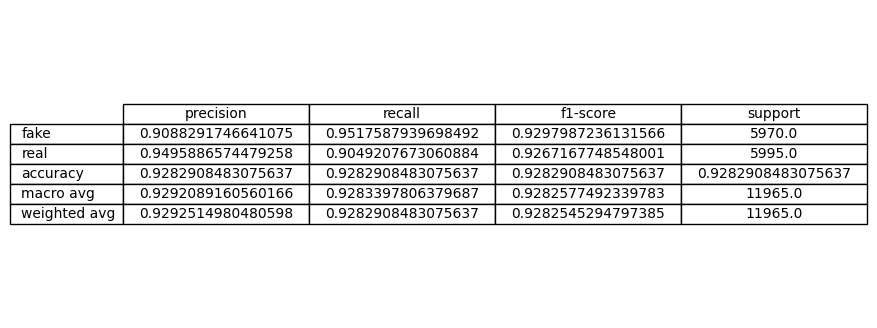

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_report.values,
                 colLabels=df_report.columns,
                 rowLabels=df_report.index,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_cnn_vit_postfinetuning_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

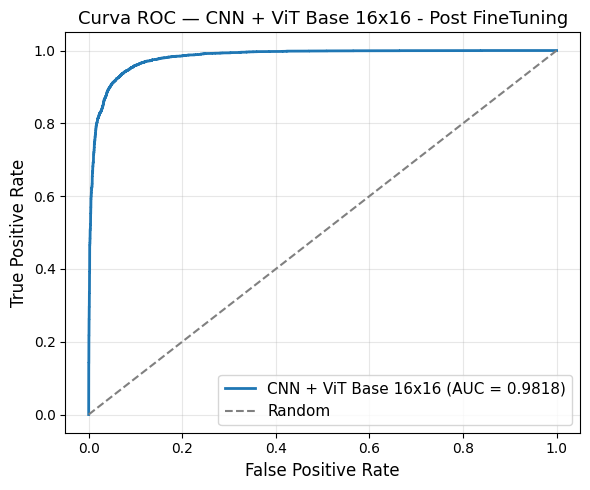

AUC final (test completo): 0.9818


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'CNN + ViT Base 16x16 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — CNN + ViT Base 16x16 - Post FineTuning', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_cnn_vit_postfinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")